# SIR + SEIR - Epidemics

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# SIR: new cases

In [64]:
def sir_model(y, t, beta, gamma, N):
    S, I, R = y # current counts of suceptible, infected, recovered
    dSdt = -beta * S * I / N # change of suceptible wrt change in time
    dIdt = beta * S * I / N - gamma * I # change of infected wrt change in time
    dRdt = gamma * I # change in recovered wrt change in time
    return dSdt, dIdt, dRdt # return change of states

In [65]:
def simulate_sir(S0, I0, R0, t, beta, gamma, N):
    '''
    INPUT:
    S0, I0, R0 = The initial counts of susceptible, infected, and recovered individuals.
    t = An array or list of time points at which to evaluate the model
    beta = transmision rate of disease
    gamma = recovery rate of disease
    N = population
    OUTPUT:
    result = array where each row corresponds to a time point and the columns represent the values of S, I, and R respectively
    '''
    y0 = (S0, I0, R0) 
    result = odeint(sir_model, y0, t, args=(beta, gamma, N)) # use odeint to solve the differential equations defined in sir_model
    # derivate at each t in the time_vector to give the paths of S,I,R
    S, I, R = result.T
    return S, I, R

In [84]:
df = pd.read_csv('../Data/silver/covid_data_weekly.csv')  
data = df[df['country']=='Chile']
data = data[data['new_cases'] > 0].reset_index(drop=True)
t_data = np.arange(1, len(data)+1)
I_data = data['new_cases'].values
N = 40_000_000  # Replace with the actual population size

In [85]:
# initial conditions
I0 = I_data[0] # infected
S0 = N - I0 # suceptible
R0 = 0 # recovered / death

In [86]:
# fit function
def fit_function(t, beta, gamma):
    S, I, R = simulate_sir(S0, I0, R0, t, beta, gamma, N)
    return I

In [87]:
beta_guess = 0.5  # Initial guess for transmission rate
gamma_guess = 0.3  # Initial guess for recovery rate
initial_guess = [beta_guess, gamma_guess]

popt, pcov = curve_fit(fit_function, t_data, I_data, p0=initial_guess)
beta_opt, gamma_opt = popt

In [88]:
t_sim = np.linspace(0, t_data[-1], 100)  # Time points for simulation
S_opt, I_opt, R_opt = simulate_sir(S0, I0, R0, t_sim, beta_opt, gamma_opt, N)

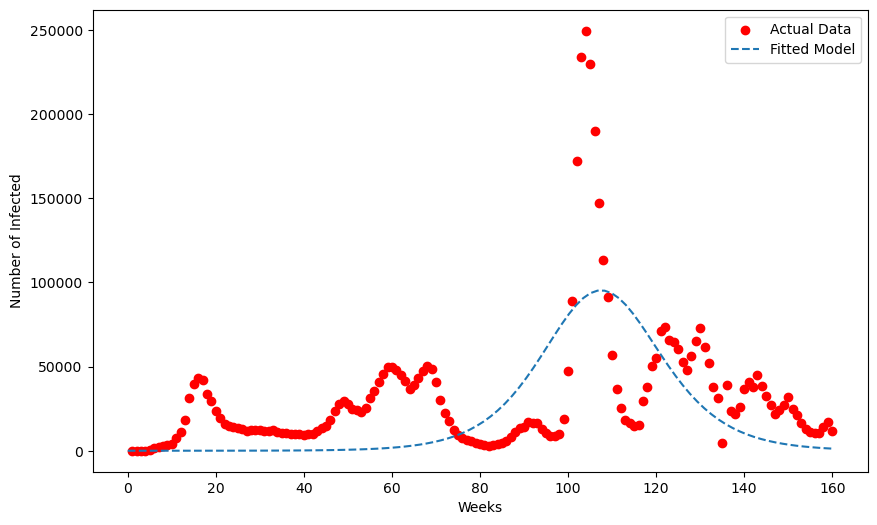

Optimized beta: 1.6624976016618682
Optimized gamma: 1.5490565086177401
Basic Reproduction Number R0: 1.0732323788144786


In [89]:
plt.figure(figsize=(10, 6))
plt.scatter(t_data, I_data, label='Actual Data', color='red')
plt.plot(t_sim, I_opt, label='Fitted Model', linestyle='dashed')
plt.xlabel('Weeks')
plt.ylabel('Number of Infected')
plt.legend()
plt.show()

print(f"Optimized beta: {beta_opt}")
print(f"Optimized gamma: {gamma_opt}")
print(f"Basic Reproduction Number R0: {beta_opt / gamma_opt}")

# SIR Cumulative

In [99]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

In [100]:
# SIR model equations
def sir_model(y, t, beta, gamma, N):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return dSdt, dIdt, dRdt

# Simulate cumulative SIR cases
def simulate_sir(S0, I0, R0, t, beta, gamma, N):
    y0 = (S0, I0, R0)
    result = odeint(sir_model, y0, t, args=(beta, gamma, N))
    S, I, R = result.T
    cumulative = N - S
    return cumulative

# Fit function for curve fitting
def fit_function(t, beta, gamma):
    return simulate_sir(S0, I0, R0, t, beta, gamma, N)

In [101]:
country_pop_dict = {'Brazil': 208126926,
 'Chile': 19331414,
 'Colombia': 50326931,
 'Dominican Republic': 10948573,
 'Germany': 83634807,
 'Italy': 60041302,
 'Mexico': 126356930,
 'Panama': 4267228,
 'US': 339142428,
 'Uruguay': 3397691}

## All countries

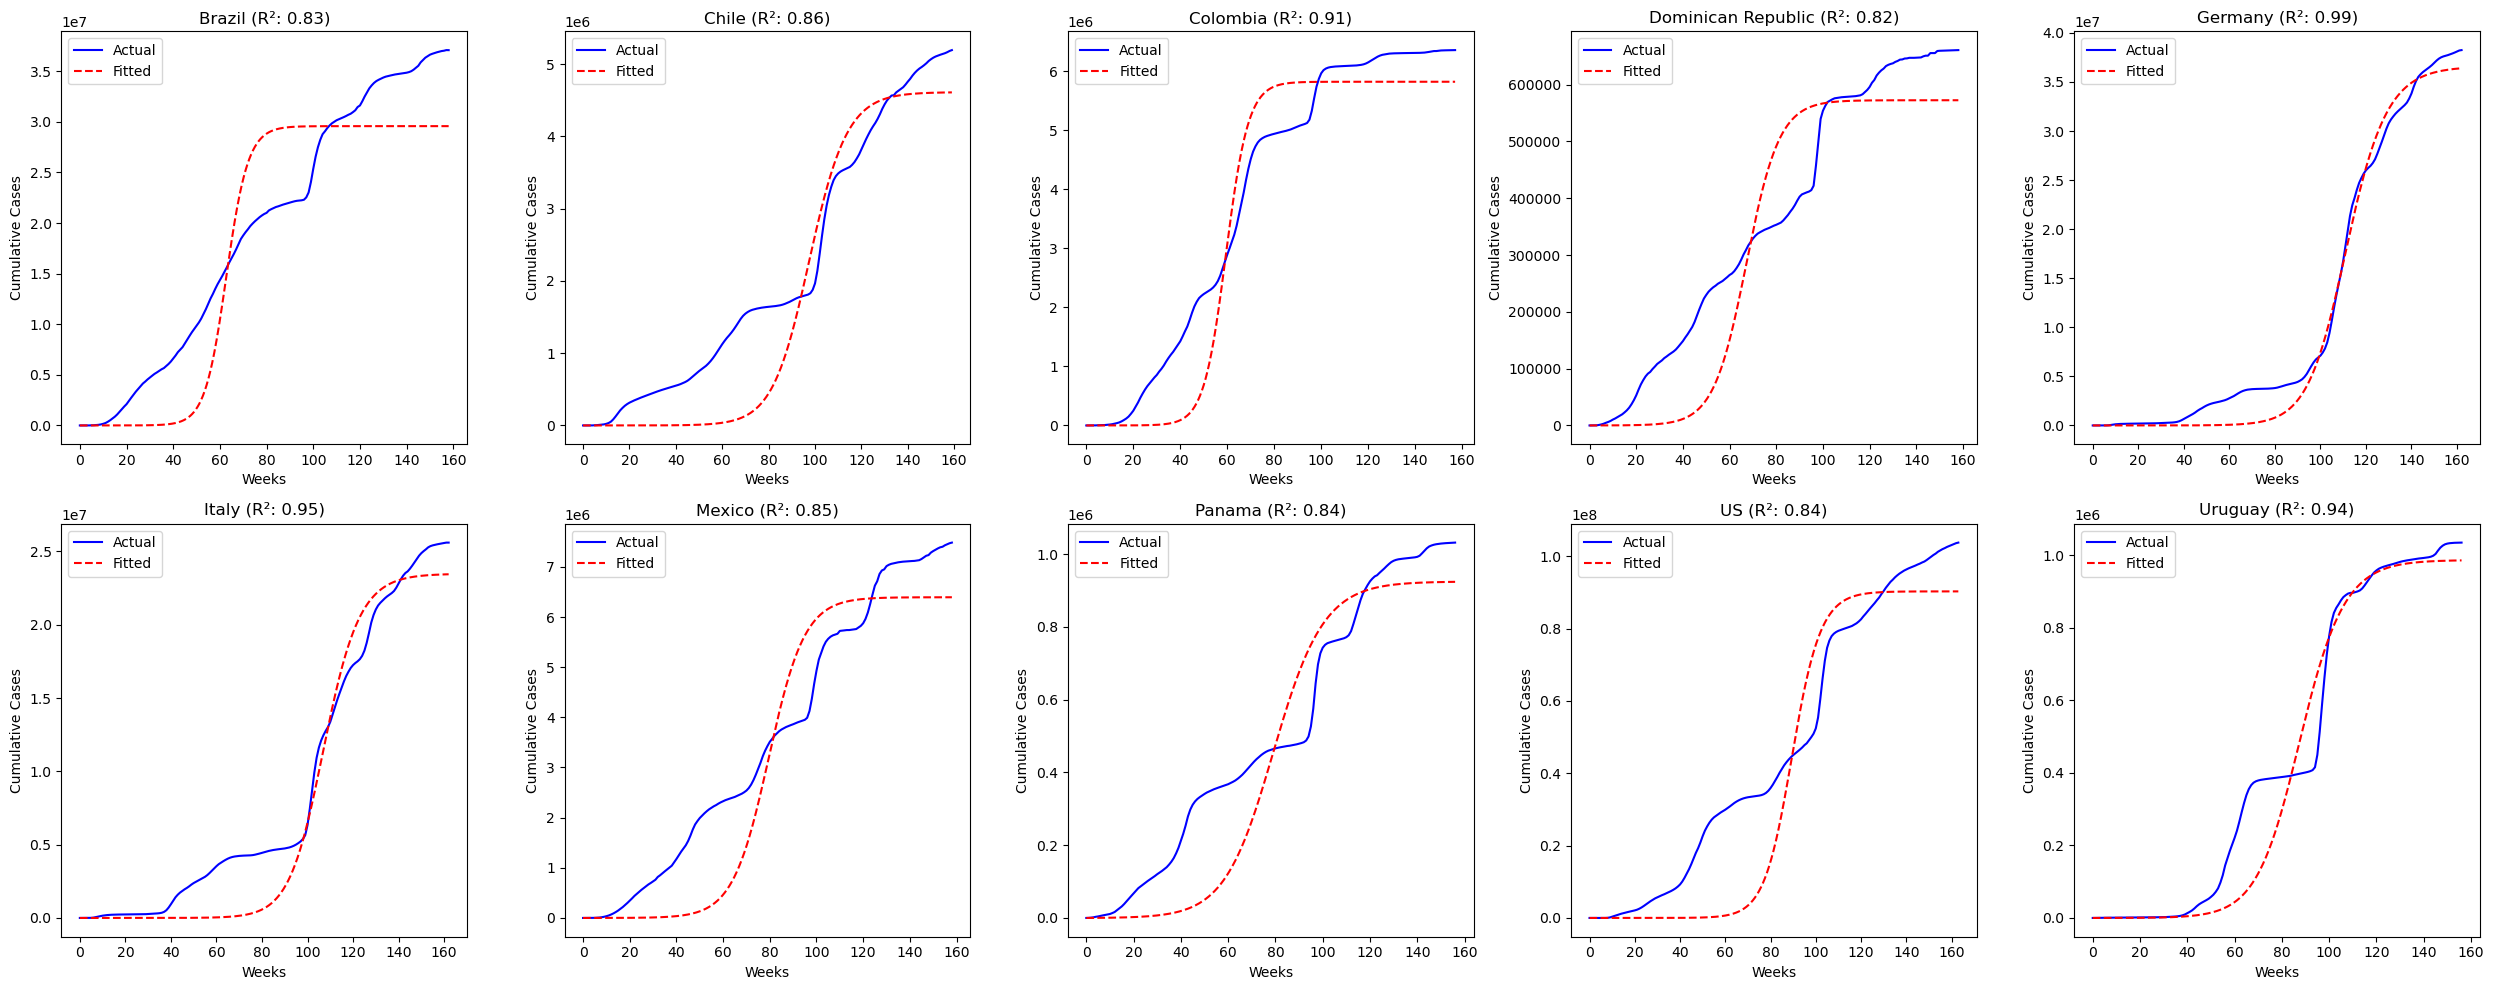

In [111]:
fig, axes = plt.subplots(2, 5, figsize=(25, 10), sharex=False, sharey=False)
axes = axes.flatten()
evaluation_metrics = {}

for idx, country in enumerate(list(country_pop_dict.keys())[:10]):
    # Filter data for country
    data = df[df['country'] == country].copy()
    data = data[data['cases'] > 0].reset_index(drop=True)

    # Prepare data
    t_data = np.arange(len(data))
    C_data = np.cumsum(data['new_cases'].values)
    N = country_pop_dict[country]

    # Initial conditions (first week of cumulative cases)
    I0 = C_data[0]
    R0 = 0
    S0 = N - I0 - R0

    # Initial parameter guesses (weekly scale)
    initial_guess = [0.5, 0.3]  # Adjust if necessary

    # Curve fitting
    popt, pcov = curve_fit(fit_function, t_data, C_data, p0=initial_guess, bounds=(0, np.inf))
    beta_opt, gamma_opt = popt

    # Simulate optimal model
    t_sim = np.linspace(0, len(t_data)-1, len(t_data)*10)
    cumulative_sim = simulate_sir(S0, I0, R0, t_sim, beta_opt, gamma_opt, N)

    # Evaluate metrics at actual data points
    cumulative_pred = simulate_sir(S0, I0, R0, t_data, beta_opt, gamma_opt, N)
    rmse = np.sqrt(mean_squared_error(C_data, cumulative_pred))
    r2 = r2_score(C_data, cumulative_pred)
    evaluation_metrics[country] = {'RMSE': rmse, 'R2': r2, 'beta': beta_opt, 'gamma': gamma_opt, 'R0': beta_opt/gamma_opt}

    # Plot
    ax = axes[idx]
    ax.plot(t_data, C_data, label='Actual', color='blue')
    ax.plot(t_sim, cumulative_sim, label='Fitted', color='red', linestyle='--')
    ax.set_title(f'{country} (R²: {r2:.2f})')
    ax.set_xlabel('Weeks')
    ax.set_ylabel('Cumulative Cases')
    ax.legend()

plt.tight_layout()
plt.show()

In [112]:
# Display evaluation metrics
metrics_df = pd.DataFrame.from_dict(evaluation_metrics, orient='index')
metrics_df

,RMSE,R2,beta,gamma,R0
Brazil,5.303174e+06,0.825083,3.043154,2.821460,1.078574
Chile,6.559192e+05,0.859297,1.036654,0.907430,1.142407
Colombia,7.105782e+05,0.912618,3.637491,3.422747,1.062740
Dominican Republic,9.643134e+04,0.823907,5.430377,5.287131,1.027093
Germany,1.708265e+06,0.985185,0.515338,0.391887,1.315016
Italy,2.103317e+06,0.946831,0.652346,0.514308,1.268396
Mexico,9.947630e+05,0.849437,5.124999,4.994210,1.026188
Panama,1.406337e+05,0.839753,0.875854,0.777129,1.127037
US,1.474916e+07,0.837213,1.197825,1.030120,1.162802
Uruguay,9.712494e+04,0.943608,0.736578,0.623591,1.181189


In [109]:
metrics_df[['R2', 'RMSE']]

,R2,RMSE
Brazil,0.825126,5.285818e+06
Chile,0.859297,6.559192e+05
Colombia,0.912297,7.117433e+05
Dominican Republic,0.817735,9.684215e+04
Germany,0.984884,1.726783e+06
Italy,0.945160,2.120841e+06
Mexico,0.848349,9.992665e+05
Panama,0.839753,1.406337e+05
US,0.837213,1.474916e+07
Uruguay,0.942547,9.766794e+04


# SEIR

**Definition of SEIR**
Model has:
* *S* Suceptible individuals
* *E* exposed individuals (not yet infectious)
* *I* infectious* individuals
* *R* recovered individuals

Model is described by set of differential equations:

$$
\begin{aligned}
\dot{S} &= -\beta \frac{SI}{N} \\
\dot{E} &= \beta \frac{SI}{N} - \sigma E \\
\dot{I} &= \sigma E  - \gamma I \\
\dot{R} &=  \gamma I
\end{aligned}
$$

With:
* $\beta$ transmision rate
* $\sigma$ incubation rate (1/inucbation period)
* $\gamma$ recovery rate (1/infectious period )
* *N* total popualtion

In [114]:
# Define SEIR equations
def seir_model(y, t, beta, gamma, sigma, N):
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I
    return dSdt, dEdt, dIdt, dRdt

# Simulate and return cumulative cases
def simulate_seir(S0, E0, I0, R0, t, beta, gamma, sigma, N):
    y0 = (S0, E0, I0, R0)
    result = odeint(seir_model, y0, t, args=(beta, gamma, sigma, N))
    S, E, I, R = result.T
    cumulative = N - S  # Cumulative cases = N - S(t)
    return cumulative, I, R

# Fit function for curve_fit; extra parameters are passed in via a lambda below.
def fit_function_seir(t, beta, gamma, sigma, N, S0, E0, I0, R0):
    cumulative, _, _ = simulate_seir(S0, E0, I0, R0, t, beta, gamma, sigma, N)
    return cumulative

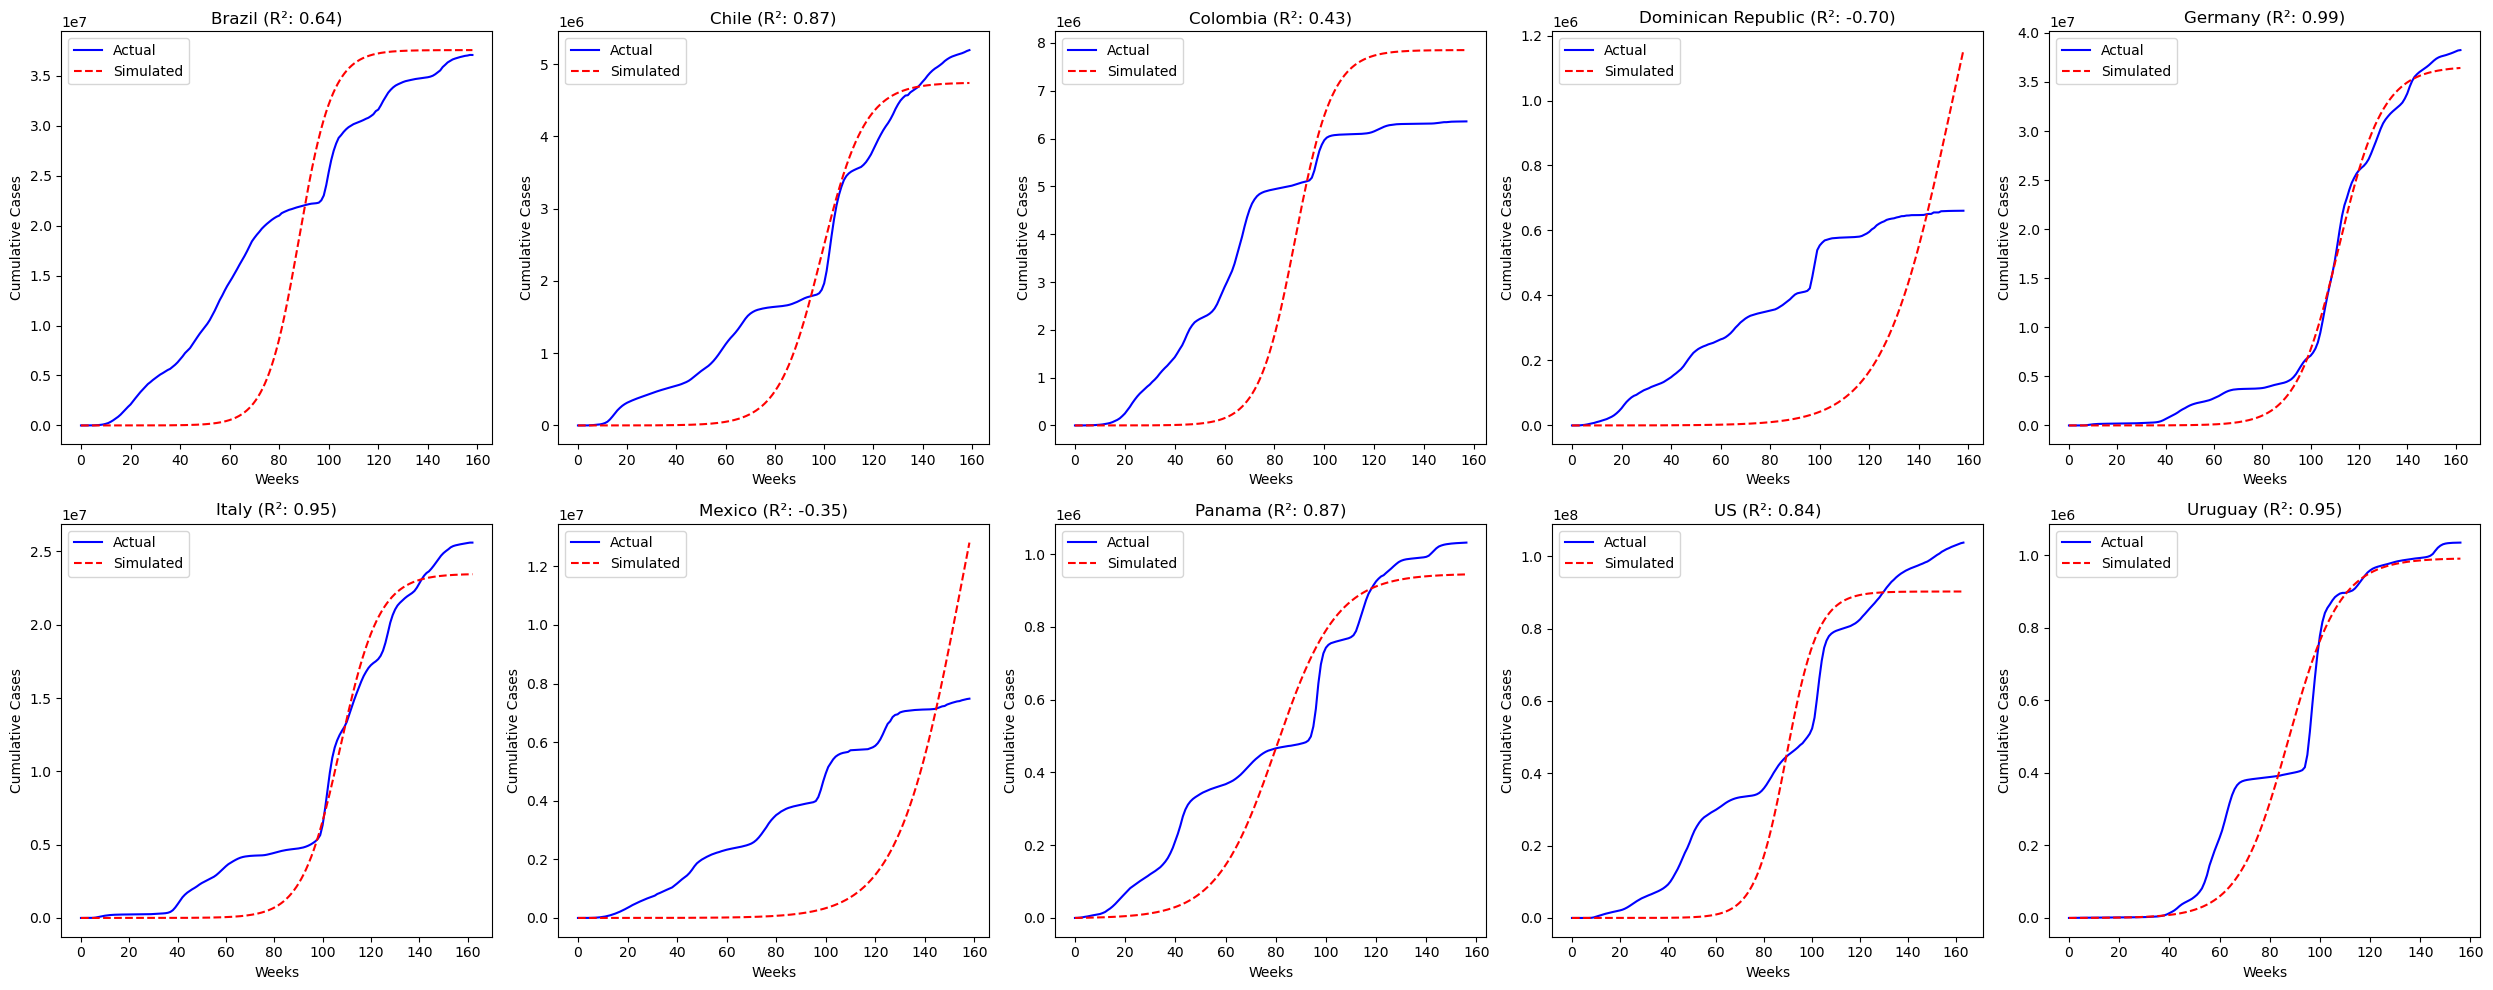

In [117]:
# Assume df and country_pop_dict are already loaded and defined
fig, axes = plt.subplots(2, 5, figsize=(25, 10), sharex=False, sharey=False)
axes = axes.flatten()
evaluation_metrics_seir = {}

for idx, country in enumerate(list(country_pop_dict.keys())[:10]):
    data = df[df['country'] == country].copy()
    data = data[data['cases'] > 0].reset_index(drop=True)

    t_data = np.arange(len(data))
    C_data = np.cumsum(data['new_cases'].values)
    N = country_pop_dict[country]

    # Initial conditions
    I0 = C_data[0]
    E0 = I0 * 2
    R0 = 0
    S0 = N - I0 - E0 - R0

    # Initial parameter guesses
    initial_guess = [1.0, 0.5, 0.5]

    # Fit the model using lambda to pass fixed parameters
    popt, pcov = curve_fit(
        lambda t, beta, gamma, sigma: fit_function_seir(t, beta, gamma, sigma, N, S0, E0, I0, R0),
        t_data,
        C_data,
        p0=initial_guess,
        bounds=(0, np.inf)
    )

    beta_opt, gamma_opt, sigma_opt = popt

    # Simulate with optimized parameters
    t_sim = np.linspace(0, len(t_data)-1, len(t_data)*10)
    cumulative_sim, _, _ = simulate_seir(S0, E0, I0, R0, t_sim, beta_opt, gamma_opt, sigma_opt, N)

    # Metrics
    cumulative_pred, _, _ = simulate_seir(S0, E0, I0, R0, t_data, beta_opt, gamma_opt, sigma_opt, N)
    rmse = np.sqrt(mean_squared_error(C_data, cumulative_pred))
    r2 = r2_score(C_data, cumulative_pred)

    evaluation_metrics_seir[country] = {
        'RMSE': rmse,
        'R2': r2,
        'beta': beta_opt,
        'gamma': gamma_opt,
        'sigma': sigma_opt,
        'R0': beta_opt / gamma_opt
    }

    # Plot
    ax = axes[idx]
    ax.plot(t_data, C_data, label='Actual', color='blue')
    ax.plot(t_sim, cumulative_sim, label='Simulated', linestyle='--', color='red')
    ax.set_title(f'{country} (R²: {r2:.2f})')
    ax.set_xlabel('Weeks')
    ax.set_ylabel('Cumulative Cases')
    ax.legend()

plt.tight_layout()
plt.show()


In [118]:
# Display evaluation metrics
metrics_seir_df = pd.DataFrame.from_dict(evaluation_metrics_seir, orient='index')
metrics_seir_df

,RMSE,R2,beta,gamma,sigma,R0
Brazil,7.558374e+06,0.644683,2.398379,2.174755,4.843144,1.102827
Chile,6.342785e+05,0.868428,1.184970,1.032790,3.798494,1.147349
Colombia,1.813809e+06,0.430644,1.794633,1.650697,49.970760,1.087197
Dominican Republic,3.000313e+05,-0.704662,1.209698,1.096699,2.060799,1.103035
Germany,1.646926e+06,0.986229,1.261769,0.959441,0.638289,1.315108
Italy,2.056768e+06,0.949159,1.096200,0.864252,1.203895,1.268381
Mexico,2.976087e+06,-0.347625,1.226783,1.110487,2.307702,1.104726
Panama,1.283886e+05,0.866444,1.072498,0.948741,2.191988,1.130444
US,1.440751e+07,0.844667,1.377179,1.184438,5.625407,1.162728
Uruguay,8.965920e+04,0.951944,0.941415,0.796194,2.008768,1.182394


In [119]:
metrics_seir_df[['R2', 'RMSE']]

,R2,RMSE
Brazil,0.644683,7.558374e+06
Chile,0.868428,6.342785e+05
Colombia,0.430644,1.813809e+06
Dominican Republic,-0.704662,3.000313e+05
Germany,0.986229,1.646926e+06
Italy,0.949159,2.056768e+06
Mexico,-0.347625,2.976087e+06
Panama,0.866444,1.283886e+05
US,0.844667,1.440751e+07
Uruguay,0.951944,8.965920e+04
